In [1]:
%matplotlib inline

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as st

# Data Cleaning
## Live Demos

In [4]:
jobs_data = pd.read_csv("data/ai-market-trends/ai_job_dataset.csv")

In [5]:
jobs_data1 = pd.read_csv("data/ai-market-trends/ai_job_dataset1.csv")

In [7]:
set(jobs_data.job_id).symmetric_difference(set(jobs_data1.job_id))

set()

In [8]:
jobs_data.columns, jobs_data1.columns

(Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
        'experience_level', 'employment_type', 'company_location',
        'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
        'education_required', 'years_experience', 'industry', 'posting_date',
        'application_deadline', 'job_description_length', 'benefits_score',
        'company_name'],
       dtype='object'),
 Index(['job_id', 'job_title', 'salary_usd', 'salary_currency', 'salary_local',
        'experience_level', 'employment_type', 'company_location',
        'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
        'education_required', 'years_experience', 'industry', 'posting_date',
        'application_deadline', 'job_description_length', 'benefits_score',
        'company_name'],
       dtype='object'))

In [10]:
jobs_data[jobs_data.duplicated()]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name


there are not duplicated records (meaning all their fields are the same) because each and every record has its own unique id

In [11]:
jobs_data[jobs_data.duplicated("job_title")

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
7,AI00008,NLP Engineer,70640,EUR,EN,FL,France,L,France,0,"Python, SQL, Computer Vision, Java, Azure",Master,0,Healthcare,2024-06-07,2024-07-01,1286,7.6,Cloud AI Solutions
9,AI00010,AI Software Engineer,102557,USD,SE,PT,Austria,M,Austria,0,"MLOps, GCP, Scala, Azure, Linux",Master,5,Government,2024-10-20,2024-11-06,2340,5.8,Cloud AI Solutions
11,AI00012,AI Architect,115047,USD,EX,CT,South Korea,S,South Korea,0,"R, Data Visualization, Python, Azure",Master,15,Manufacturing,2024-07-16,2024-08-19,513,6.8,TechCorp Inc
12,AI00013,AI Consultant,124355,EUR,SE,CT,France,M,France,100,"Tableau, Python, TensorFlow",PhD,5,Automotive,2024-12-29,2025-01-27,760,5.2,Predictive Systems
13,AI00014,Autonomous Systems Engineer,68760,USD,EN,CT,Norway,S,Norway,0,"Scala, SQL, Statistics",Master,0,Energy,2024-02-11,2024-02-25,1657,9.1,Cloud AI Solutions
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


In [14]:
jobs_data.drop_duplicates(["job_title", "salary_usd"])

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


In [15]:
jobs_data.shape

(15000, 19)

In [16]:
jobs_data.dtypes

job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object

In [17]:
jobs_data.head(10)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
5,AI00006,AI Architect,123574,EUR,SE,CT,Germany,M,Germany,50,"Data Visualization, R, SQL, Linux",Associate,7,Healthcare,2024-08-31,2024-10-04,819,5.9,Neural Networks Co
6,AI00007,Principal Data Scientist,79670,GBP,MI,FL,United Kingdom,S,United Kingdom,0,"R, Docker, MLOps",Associate,3,Gaming,2024-12-29,2025-02-28,1936,6.3,DataVision Ltd
7,AI00008,NLP Engineer,70640,EUR,EN,FL,France,L,France,0,"Python, SQL, Computer Vision, Java, Azure",Master,0,Healthcare,2024-06-07,2024-07-01,1286,7.6,Cloud AI Solutions
8,AI00009,Data Analyst,160710,USD,SE,CT,Singapore,L,Singapore,0,"Hadoop, Git, Mathematics, Python",PhD,7,Government,2024-11-04,2024-11-24,551,9.3,Quantum Computing Inc
9,AI00010,AI Software Engineer,102557,USD,SE,PT,Austria,M,Austria,0,"MLOps, GCP, Scala, Azure, Linux",Master,5,Government,2024-10-20,2024-11-06,2340,5.8,Cloud AI Solutions


In [20]:
jobs_data.sample(20)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
12938,AI12939,AI Architect,58147,USD,MI,PT,Finland,S,South Korea,50,"Data Visualization, SQL, Spark",PhD,4,Consulting,2025-02-16,2025-04-23,2140,7.0,DeepTech Ventures
4086,AI04087,Data Scientist,56585,USD,MI,FL,Austria,M,India,50,"Deep Learning, R, PyTorch, Scala",Master,3,Healthcare,2024-11-28,2025-02-09,2167,10.0,Advanced Robotics
5750,AI05751,AI Research Scientist,74149,USD,EN,FT,Singapore,L,Singapore,100,"SQL, AWS, Tableau, Kubernetes",Associate,1,Energy,2025-04-09,2025-05-14,1349,5.2,Quantum Computing Inc
10800,AI10801,Robotics Engineer,139252,USD,EX,PT,Austria,M,Austria,100,"Azure, Tableau, PyTorch",PhD,15,Technology,2024-03-18,2024-04-26,2078,6.6,Cloud AI Solutions
8186,AI08187,Research Scientist,130341,USD,EX,PT,Canada,M,Canada,50,"Scala, Statistics, Hadoop, Spark, Git",PhD,12,Government,2024-04-24,2024-06-05,710,8.4,Advanced Robotics
12798,AI12799,AI Specialist,270238,USD,EX,PT,Switzerland,L,Switzerland,50,"MLOps, Git, R, Computer Vision",PhD,15,Energy,2024-11-19,2025-01-11,1578,9.4,Predictive Systems
7795,AI07796,Principal Data Scientist,92753,USD,EX,CT,Finland,S,Finland,50,"GCP, Git, Tableau, NLP, MLOps",Master,16,Real Estate,2024-09-06,2024-11-14,2281,9.2,Digital Transformation LLC
14319,AI14320,AI Research Scientist,73776,USD,EN,FL,United States,M,United States,100,"Deep Learning, R, Kubernetes",PhD,0,Automotive,2025-01-31,2025-02-18,1196,5.0,Quantum Computing Inc
6021,AI06022,AI Architect,132228,EUR,EX,PT,Netherlands,S,United Kingdom,50,"Python, TensorFlow, Computer Vision, GCP, Spark",Bachelor,11,Real Estate,2025-03-08,2025-04-12,1435,9.2,Autonomous Tech
4530,AI04531,ML Ops Engineer,62554,USD,MI,PT,South Korea,L,South Korea,0,"Java, Python, Git, Computer Vision, Scala",PhD,2,Finance,2024-10-09,2024-10-23,658,6.3,Digital Transformation LLC


In [21]:
jobs_data.job_id.nunique()

15000

In [22]:
jobs_data.job_id.nunique() == len(jobs_data)

True

In [23]:
jobs_data.set_index("job_id")

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
job_id,,,,,,,,,,,,,,,,,,
AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations


the column job_id has a big entropy so it won't be good for modelling. Instead it can be useful for referring to data

In [24]:
jobs_data[
    jobs_data.job_id == "AI05713"
]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
5712,AI05713,AI Research Scientist,54940,USD,EN,PT,Austria,M,Austria,50,"SQL, Linux, PyTorch",Associate,1,Education,2024-06-02,2024-06-29,1014,5.1,Digital Transformation LLC


In [26]:
jobs_data.salary_currency.value_counts(dropna = False)

salary_currency
USD    11957
EUR     2314
GBP      729
Name: count, dtype: int64

value_counts() drops values that are NaN

In [27]:
jobs_data.company_location.value_counts()

company_location
Germany           814
Denmark           778
Canada            769
France            769
Austria           765
Singapore         764
China             763
India             754
Sweden            752
Israel            751
Ireland           750
Switzerland       746
Japan             733
Finland           733
Australia         732
Netherlands       731
United Kingdom    729
United States     724
South Korea       722
Norway            721
Name: count, dtype: int64

In [28]:
jobs_data.remote_ratio.value_counts()

remote_ratio
0      5075
50     5005
100    4920
Name: count, dtype: int64

In [29]:
jobs_data.remote_ratio = jobs_data.remote_ratio.replace({0: "Onsite", 50: "Hybrid", 100: "Remote"})

In [30]:
jobs_data.remote_ratio

0        Hybrid
1        Remote
2        Onsite
3        Hybrid
4        Remote
          ...  
14995    Hybrid
14996    Onsite
14997    Hybrid
14998    Onsite
14999    Hybrid
Name: remote_ratio, Length: 15000, dtype: object

In [35]:
jobs_data.experience_level = jobs_data.experience_level.astype("category")

In [36]:
jobs_data.experience_level.value_counts()

experience_level
MI    3781
EX    3760
SE    3741
EN    3718
Name: count, dtype: int64

In [38]:
jobs_data.pivot_table(columns = "experience_level", index = "company_size", aggfunc = "size")

C:\Users\aneli\AppData\Local\Temp\ipykernel_7052\210351302.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  jobs_data.pivot_table(columns = "experience_level", index = "company_size", aggfunc = "size")


experience_level,EN,EX,MI,SE
company_size,,,,
L,1214,1201,1284,1299
M,1237,1263,1277,1218
S,1267,1296,1220,1224


In [42]:
st.chi2_contingency(jobs_data.pivot_table(columns = "experience_level", index = "company_size", aggfunc = "size"))

C:\Users\aneli\AppData\Local\Temp\ipykernel_7052\1856348833.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  st.chi2_contingency(jobs_data.pivot_table(columns = "experience_level", index = "company_size", aggfunc = "size"))


Chi2ContingencyResult(statistic=np.float64(10.056921001575674), pvalue=np.float64(0.12227532866081985), dof=6, expected_freq=array([[1238.8376, 1252.832 , 1259.8292, 1246.5012],
       [1238.094 , 1252.08  , 1259.073 , 1245.753 ],
       [1241.0684, 1255.088 , 1262.0978, 1248.7458]]))

In [44]:
jobs_data.job_title.value_counts()

job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Robotics Engineer              759
Data Analyst                   759
AI Research Scientist          756
Data Engineer                  749
AI Product Manager             743
Research Scientist             742
Principal Data Scientist       734
AI Specialist                  728
ML Ops Engineer                725
Computer Vision Engineer       724
Data Scientist                 720
Deep Learning Engineer         718
AI Consultant                  704
Name: count, dtype: int64

In [46]:
jobs_data[jobs_data.job_title == "Head of AI"].company_size.value_counts()

company_size
M    283
L    246
S    236
Name: count, dtype: int64

In [47]:
jobs_data[jobs_data.job_title == "Machine Learning Researcher"].company_size.value_counts()

company_size
S    293
M    270
L    245
Name: count, dtype: int64

In [50]:
jobs_data.posting_date = pd.to_datetime(jobs_data.posting_date)

In [51]:
jobs_data.posting_date

0       2024-10-18
1       2024-11-20
2       2025-03-18
3       2024-12-23
4       2025-04-15
           ...    
14995   2025-02-06
14996   2024-10-16
14997   2024-03-19
14998   2024-03-22
14999   2024-07-18
Name: posting_date, Length: 15000, dtype: datetime64[ns]

In [52]:
jobs_data.application_deadline = pd.to_datetime(jobs_data.application_deadline)

In [54]:
jobs_data["days_left_to_apply"] = jobs_data.application_deadline - jobs_data.posting_date

In [55]:
jobs_data.days_left_to_apply.value_counts()

days_left_to_apply
66 days    283
60 days    277
58 days    276
39 days    273
27 days    268
          ... 
19 days    229
64 days    227
23 days    222
43 days    201
74 days      2
Name: count, Length: 61, dtype: int64

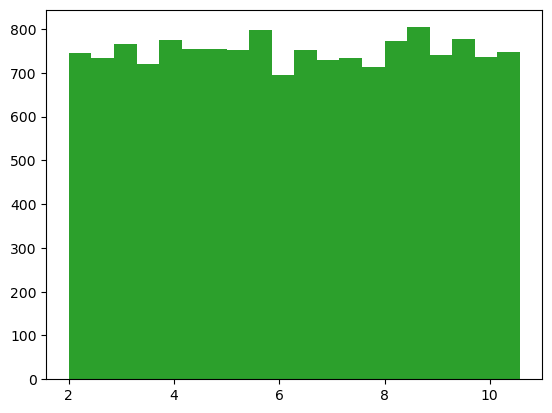

In [62]:
plt.hist(jobs_data.days_left_to_apply.dt.days / 7, bins = 20)
plt.show()

In [63]:
jobs_data.days_left_to_apply.dt.days.describe()

count    15000.000000
mean        43.546200
std         17.325134
min         14.000000
25%         29.000000
50%         44.000000
75%         59.000000
max         74.000000
Name: days_left_to_apply, dtype: float64

In [69]:
skills = jobs_data.required_skills.str.split(", ", expand = True)

In [70]:
skills

,0,1,2,3,4
0,Tableau,PyTorch,Kubernetes,Linux,NLP
1,Deep Learning,AWS,Mathematics,Python,Docker
2,Kubernetes,Deep Learning,Java,Hadoop,NLP
3,Scala,SQL,Linux,Python,None
4,MLOps,Java,Tableau,Python,None
...,...,...,...,...,...
14995,Java,Kubernetes,Azure,None,None
14996,Mathematics,Docker,SQL,Deep Learning,None
14997,Scala,Spark,NLP,None,None
14998,Java,Computer Vision,Python,TensorFlow,None


In [75]:
skills[skills[3] == "Deep Learning"]

,0,1,2,3,4
98,Python,AWS,Kubernetes,Deep Learning,None
116,Kubernetes,SQL,Azure,Deep Learning,Linux
128,GCP,R,Azure,Deep Learning,PyTorch
139,Linux,AWS,Computer Vision,Deep Learning,None
141,GCP,Kubernetes,Computer Vision,Deep Learning,SQL
...,...,...,...,...,...
14854,SQL,TensorFlow,Computer Vision,Deep Learning,Python
14862,Python,Java,Tableau,Deep Learning,None
14934,R,Statistics,Docker,Deep Learning,None
14972,Linux,AWS,PyTorch,Deep Learning,Tableau


In [77]:
skills[skills[0] == "Deep Learning"].index

Index([    1,    20,    30,    48,    50,    97,   162,   179,   284,   303,
       ...
       14611, 14614, 14653, 14669, 14731, 14753, 14761, 14797, 14849, 14889],
      dtype='int64', length=411)

In [78]:
jobs_data.loc[skills[skills[0] == "Deep Learning"].index]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,days_left_to_apply
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,Remote,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,52 days
20,AI00021,Data Engineer,134197,USD,MI,FT,Norway,M,France,Onsite,"Deep Learning, AWS, Azure",Bachelor,3,Telecommunications,2024-06-21,2024-08-28,969,9.6,AI Innovations,68 days
30,AI00031,Head of AI,67488,EUR,EN,FT,Netherlands,M,Netherlands,Remote,"Deep Learning, GCP, AWS, Linux, Tableau",Master,1,Retail,2024-05-16,2024-07-26,887,6.0,Advanced Robotics,71 days
48,AI00049,AI Specialist,288815,USD,EX,PT,Switzerland,S,Switzerland,Onsite,"Deep Learning, Git, Data Visualization, Linux,...",Bachelor,12,Manufacturing,2024-08-08,2024-09-23,1930,7.2,Cognitive Computing,46 days
50,AI00051,AI Architect,70391,EUR,MI,FT,Germany,S,Germany,Onsite,"Deep Learning, SQL, Mathematics",PhD,4,Government,2024-08-16,2024-10-19,1974,9.2,TechCorp Inc,64 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14753,AI14754,Data Engineer,108907,USD,SE,FL,India,L,India,Hybrid,"Deep Learning, Statistics, Azure",Associate,8,Telecommunications,2025-03-11,2025-04-08,1720,9.7,Cloud AI Solutions,28 days
14761,AI14762,AI Product Manager,111106,GBP,MI,PT,United Kingdom,L,United Kingdom,Hybrid,"Deep Learning, AWS, Python",PhD,2,Telecommunications,2024-12-13,2025-01-25,1763,5.9,Predictive Systems,43 days
14797,AI14798,Head of AI,206490,USD,EX,PT,Finland,L,Finland,Hybrid,"Deep Learning, AWS, Linux, Statistics, SQL",Bachelor,10,Manufacturing,2024-01-21,2024-03-09,1268,8.7,Cognitive Computing,48 days
14849,AI14850,Autonomous Systems Engineer,160590,EUR,SE,FT,Germany,L,Germany,Remote,"Deep Learning, R, Statistics, Kubernetes, AWS",PhD,6,Manufacturing,2024-05-08,2024-07-03,1969,8.4,Cloud AI Solutions,56 days


In [80]:
jobs_data[jobs_data.required_skills.str.contains("deep learning", case = False)]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,days_left_to_apply
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,Remote,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,52 days
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,Onsite,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,20 days
15,AI00016,AI Product Manager,78846,GBP,EN,PT,United Kingdom,L,Israel,Onsite,"Linux, Statistics, Deep Learning",PhD,0,Consulting,2024-09-28,2024-10-26,2059,9.6,DataVision Ltd,28 days
20,AI00021,Data Engineer,134197,USD,MI,FT,Norway,M,France,Onsite,"Deep Learning, AWS, Azure",Bachelor,3,Telecommunications,2024-06-21,2024-08-28,969,9.6,AI Innovations,68 days
30,AI00031,Head of AI,67488,EUR,EN,FT,Netherlands,M,Netherlands,Remote,"Deep Learning, GCP, AWS, Linux, Tableau",Master,1,Retail,2024-05-16,2024-07-26,887,6.0,Advanced Robotics,71 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14980,AI14981,AI Research Scientist,54209,USD,EN,FL,Sweden,S,Sweden,Onsite,"Docker, Git, Deep Learning, MLOps, Statistics",PhD,1,Telecommunications,2024-05-22,2024-07-13,2072,8.5,Machine Intelligence Group,52 days
14992,AI14993,Autonomous Systems Engineer,200047,USD,SE,PT,Denmark,L,Denmark,Hybrid,"Computer Vision, Data Visualization, R, Hadoop...",Associate,9,Telecommunications,2024-10-28,2024-11-15,1986,7.6,Neural Networks Co,18 days
14993,AI14994,Autonomous Systems Engineer,130671,USD,EX,CT,South Korea,M,South Korea,Onsite,"Computer Vision, Deep Learning, AWS",PhD,13,Retail,2024-07-14,2024-09-15,1167,7.1,Quantum Computing Inc,63 days
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,Onsite,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics,14 days


In [81]:
jobs_data[jobs_data.required_skills.str.contains("deep learning", case = False)].job_title.value_counts()

job_title
NLP Engineer                   125
Data Engineer                  123
Head of AI                     120
AI Software Engineer           120
Research Scientist             119
Data Scientist                 116
Machine Learning Researcher    115
Data Analyst                   113
AI Consultant                  112
Computer Vision Engineer       112
AI Research Scientist          112
Principal Data Scientist       110
Autonomous Systems Engineer    104
AI Product Manager             104
Machine Learning Engineer      104
AI Specialist                  102
AI Architect                   100
Robotics Engineer               96
Deep Learning Engineer          94
ML Ops Engineer                 88
Name: count, dtype: int64